In [1]:
#Random Forest model
#import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.ensemble import RandomForestClassifier

In [2]:
#load adatset
df = pd.read_csv('/content/dataset_B_training.csv')

df.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,h1n1_vaccine
0,1,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",2.0,1.0,science,0
1,2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Female,Below Poverty,Not Married,Own,Employed,Non-MSA,0.0,3.0,wholesale,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Female,"> $75,000",Not Married,Own,Employed,"MSA, Principle City",0.0,0.0,education,1
3,4,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Female,"<= $75,000, Above Poverty",Not Married,Rent,Not in Labor Force,Non-MSA,0.0,0.0,NaN,0
4,5,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Female,NaN,Not Married,NaN,Unemployed,Non-MSA,3.0,0.0,NaN,0


In [3]:
#summary statistics
df.describe()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,household_adults,household_children,h1n1_vaccine
count,4756.00000,4741.000000,4734.000000,4739.000000,4729.000000,4752.000000,4748.000000,4747.000000,4741.000000,4736.000000,...,4595.000000,4622.000000,4625.000000,2831.000000,4687.000000,4692.000000,4692.000000,4722.000000,4722.000000,4756.000000
mean,2378.50000,1.658933,1.307140,0.057396,0.740960,0.077652,0.842039,0.359385,0.341278,0.704814,...,0.314037,0.090437,0.141189,0.901801,3.965436,2.512361,2.412191,0.888818,0.542143,0.394029
std,1373.08327,0.892478,0.612811,0.232622,0.438154,0.267651,0.364743,0.479871,0.474189,0.456174,...,0.464182,0.286838,0.348254,0.297635,0.981737,1.336426,1.372509,0.755777,0.931243,0.488692
min,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,1189.75000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,4.000000,1.000000,1.000000,0.000000,0.000000,0.000000
50%,2378.50000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,4.000000,2.000000,2.000000,1.000000,0.000000,0.000000
75%,3567.25000,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,0.000000,1.000000,5.000000,4.000000,4.000000,1.000000,1.000000,1.000000
max,4756.00000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,5.000000,5.000000,5.000000,3.000000,3.000000,1.000000


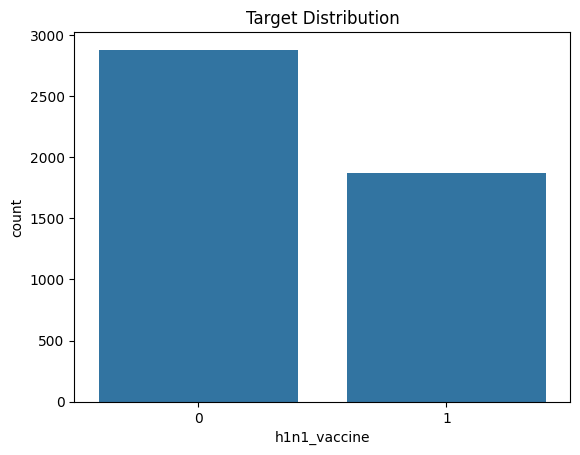

,proportion
h1n1_vaccine,
0,0.605971
1,0.394029


In [4]:
#Target analysis
sns.countplot(x='h1n1_vaccine', data=df)
plt.title("Target Distribution")
plt.show()

df['h1n1_vaccine'].value_counts(normalize=True)

In [5]:
#numerical feature analysis
num_cols = df.select_dtypes(include=np.number).columns.tolist()

num_cols.remove('h1n1_vaccine')

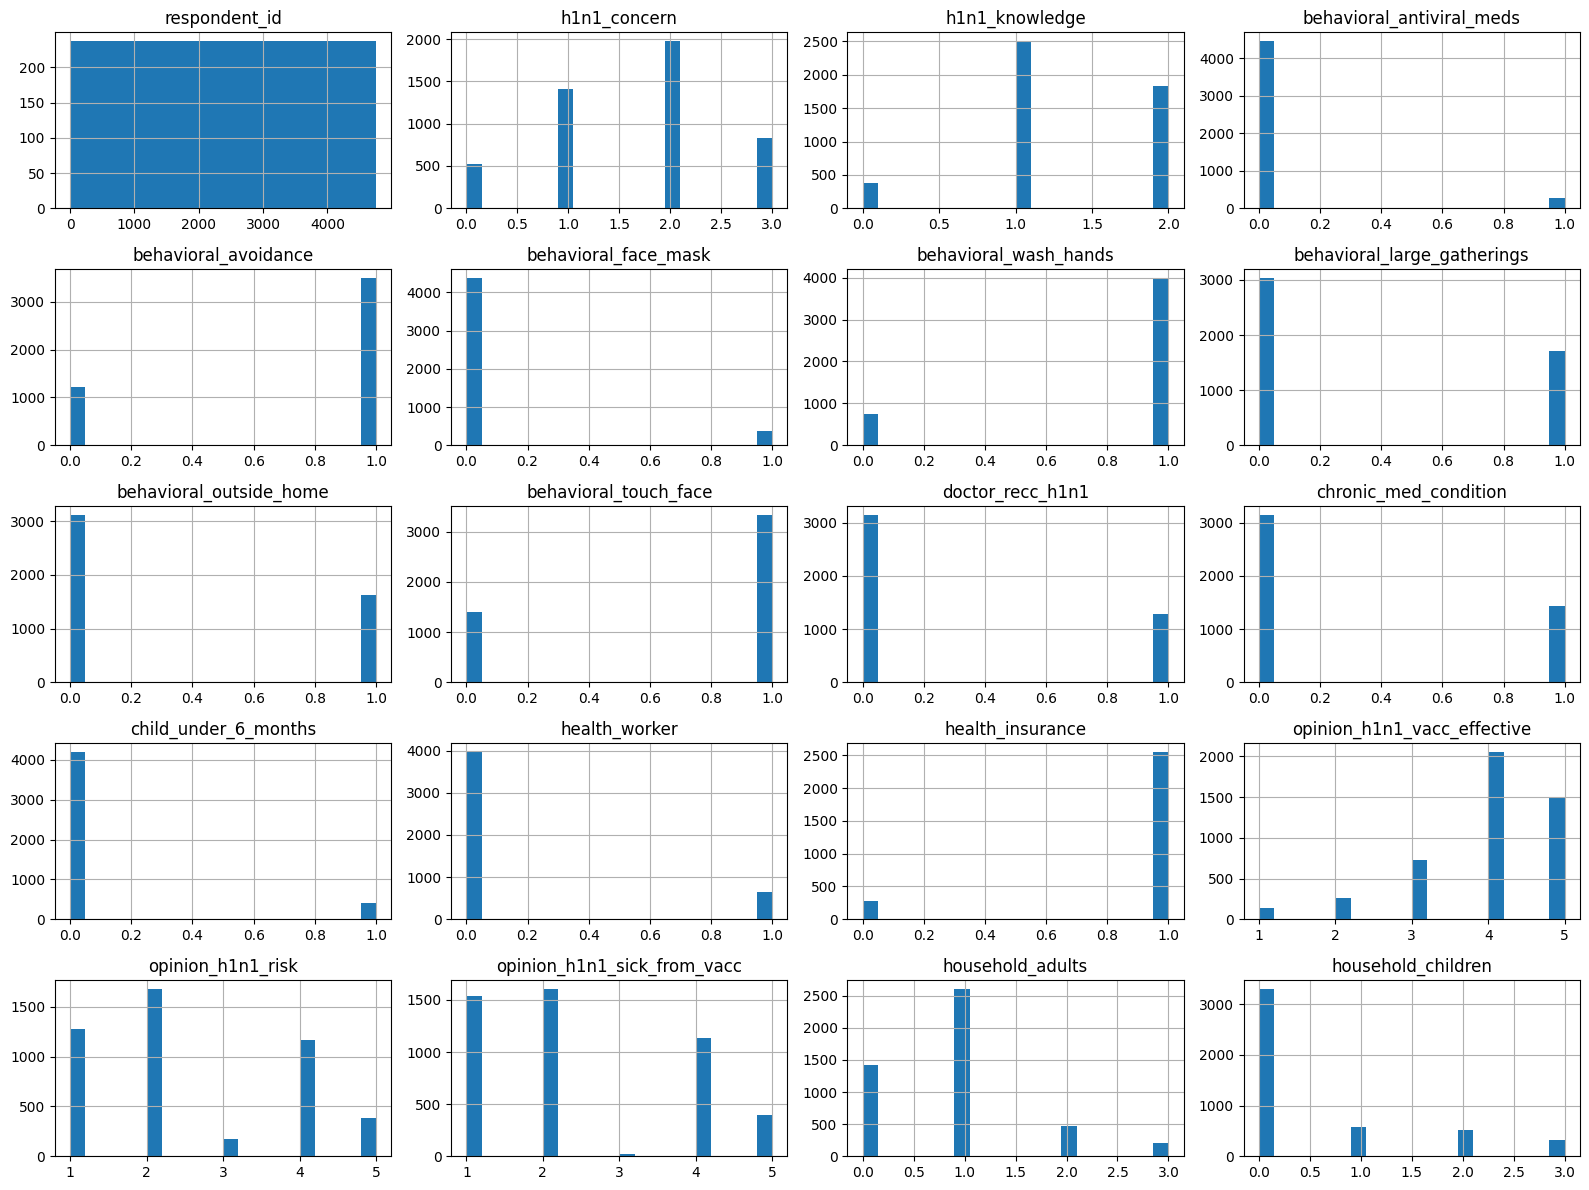

In [6]:
#EDA histogram
df[num_cols].hist(
    figsize=(16,12),
    bins=20
)

plt.tight_layout()
plt.show()

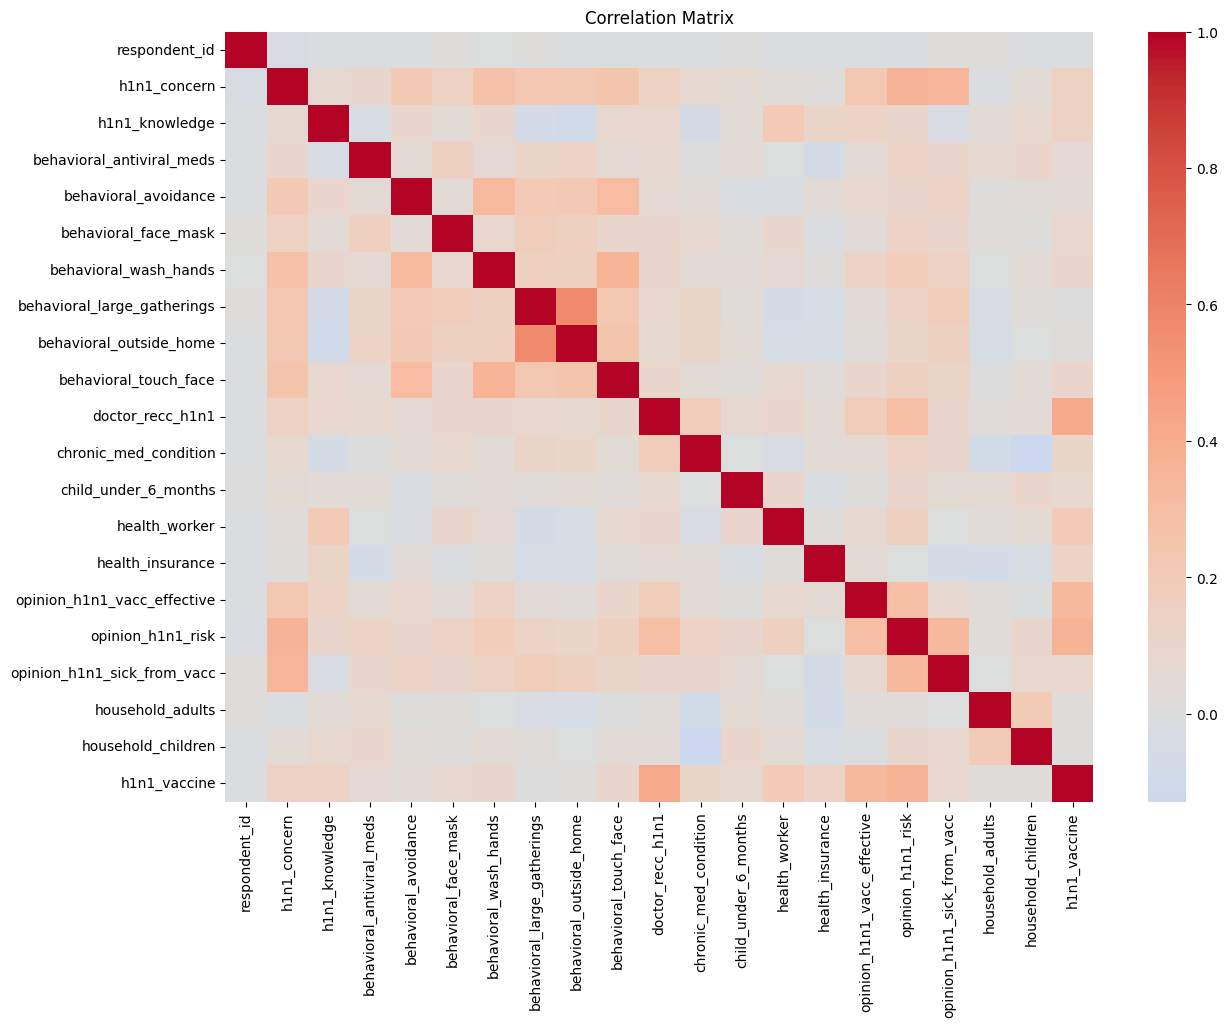

In [7]:
#correlation analysis
plt.figure(figsize=(14,10))

sns.heatmap(
    df[num_cols + ['h1n1_vaccine']].corr(),
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Matrix")
plt.show()

In [8]:
#Train-test split
#remove ID column
X = df.drop(
    ['respondent_id', 'h1n1_vaccine'],
    axis=1
)

y = df['h1n1_vaccine']

In [9]:
#Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
#Preprocessing
#numerical
numeric_features = X.select_dtypes(
    include=np.number
).columns

In [14]:
#numeric transformer
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [21]:
#categorical features
categorical_features = X.select_dtypes(
    include='object'
).columns

In [22]:
#categorical
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [24]:
#combining features
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


In [25]:
#Random forest
rf_model = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Predictions
rf_pred = rf_model.predict(X_test)

# Probabilities (needed for ROC-AUC)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, rf_pred)
precision = precision_score(y_test, rf_pred)
recall = recall_score(y_test, rf_pred)
f1 = f1_score(y_test, rf_pred)
roc_auc = roc_auc_score(y_test, rf_prob)

# Print results
print("Random Forest Results")
print("-"*30)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Results
------------------------------
Accuracy  : 0.7542
Precision : 0.7252
Recall    : 0.6053
F1 Score  : 0.6599
ROC-AUC   : 0.7884

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.85      0.81       577
           1       0.73      0.61      0.66       375

    accuracy                           0.75       952
   macro avg       0.75      0.73      0.73       952
weighted avg       0.75      0.75      0.75       952



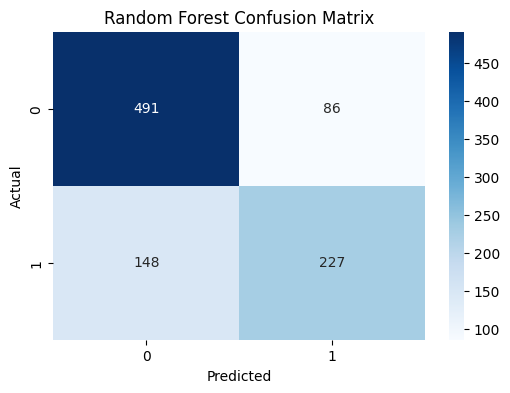

In [27]:
#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

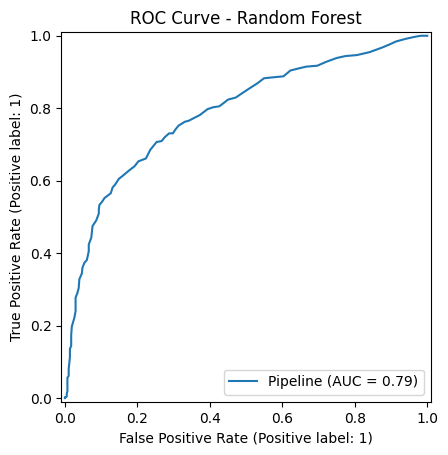

In [28]:
#ROC curve
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

plt.title("ROC Curve - Random Forest")
plt.show()

In [29]:
#Results table
results_rf = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
    'Score': [accuracy, precision, recall, f1, roc_auc]
})

print(results_rf)

      Metric     Score
0   Accuracy  0.754202
1  Precision  0.725240
2     Recall  0.605333
3   F1 Score  0.659884
4    ROC-AUC  0.788379
